In [19]:
import pandas as pd
import os
import re
#데이터 로드 및 데이터 정제

data_path = "../../data/Mobile Reviews Sentiment.csv" 

df = pd.read_csv(data_path)

# 텍스트 정제
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['cleaned_review'] = df['review_text'].apply(clean_text)


In [20]:
import numpy as np

# 1단계: 도메인 특화 불용어 및 복합 부정어 예외 패턴 정제 함수
def clean_and_detect_intent(text):
    if not isinstance(text, str):
        text = ""
    text_lower = text.lower()
    
    # 'no regrets' 같은 예외 패턴 감지 (부정어가 포함되어 있어도 실제 의도는 긍정)
    has_no_regrets = "no regrets" in text_lower or "no regret" in text_lower
    
    negative_keywords = ["bad", "poor", "drain", "lag", "heat", "overheat", "issue", "slow", "worst", "disappoint", "regret"]
    positive_keywords = ["great", "good", "excellent", "love", "amazing", "fast", "smooth", "perfect", "solid"]
    
    has_neg = any(kw in text_lower for kw in negative_keywords) and not has_no_regrets
    has_pos = any(kw in text_lower for kw in positive_keywords) or has_no_regrets
    
    return has_neg, has_pos

# 간단한 테스트 샘플로 함수 작동 여부 확인
test_reviews = [
    "Battery drains too fast and gets hot.", # 부정 리뷰
    "Build quality feels solid. No regrets at all.", # 복합 부정어 예외 케이스 (긍정 의도)
    "Does what it's supposed to, nothing special." # 중립/모호 리뷰
]

for review in test_reviews:
    neg, pos = clean_and_detect_intent(review)
    print(f"Review: {review}")
    print(f" -> 감지 결과 [Neg: {neg}, Pos: {pos}]\n")

Review: Battery drains too fast and gets hot.
 -> 감지 결과 [Neg: True, Pos: True]

Review: Build quality feels solid. No regrets at all.
 -> 감지 결과 [Neg: False, Pos: True]

Review: Does what it's supposed to, nothing special.
 -> 감지 결과 [Neg: False, Pos: False]



In [21]:
# 2단계: 감성 불일치 파이프라인 함수 정의
def advanced_sentiment_pipeline(row):
    rating = row['rating']
    has_neg, has_pos = clean_and_detect_intent(row['review_text'])
    
    # [케이스 A] 페인 포인트 그룹 (1~2점 정상 + 3점 중립 속 숨은 불만 + 고평점 역설적 불만)
    if (rating <= 2 and has_neg) or (rating == 3 and has_neg) or (rating >= 4 and has_neg and not has_pos):
        return 'Pain Point Group'
    
    # [케이스 B] 스트렝스 그룹 (4~5점 정상 + 3점 속 긍정 등)
    elif (rating >= 4 and has_pos) or (rating == 3 and has_pos) or (rating <= 2 and has_pos and not has_neg):
        return 'Strength Group'
    
    else:
        return 'General / Unclassified'

# 실제 데이터프레임에 적용
df['analysis_segment'] = df.apply(advanced_sentiment_pipeline, axis=1)

# 결과 확인 (세그먼트별 분포 집계)
print(df['analysis_segment'].value_counts())

analysis_segment
Strength Group            21420
General / Unclassified    17784
Pain Point Group          10796
Name: count, dtype: int64


In [22]:
# 1단계: 도메인 특화 불용어 및 복합 감성/반전 패턴 정제 함수 (개선 버전)
def clean_and_detect_intent(text):
    if not isinstance(text, str):
        text = ""
    text_lower = text.lower()
    
    # 1. 긍정 반전형 복합 표현 (부정어가 포함되어 있어도 실제 의도는 강력한 긍정)
    positive_idioms = [
        "no regrets", "no regret", 
        "can't go wrong", "cannot go wrong", 
        "nothing to complain", 
        "worth every penny", "well worth the money", 
        "hard to put down", "hard to beat"
    ]
    has_pos_idiom = any(idiom in text_lower for idiom in positive_idioms)
    
    # 2. 겉보기엔 긍정이나 반전 불만이 숨어있는 표현 (주의 패턴)
    hidden_negative_idioms = [
        "not bad, but", 
        "too good to be true",
        "good, but", 
        "great, but",
        "expected more from",
        "not as good as",
        "overhyped",
        "left a lot to be desired"
    ]
    has_hidden_neg = any(idiom in text_lower for idiom in hidden_negative_idioms)
    
    # 기본 키워드 정의
    negative_keywords = ["bad", "poor", "drain", "lag", "heat", "overheat", "issue", "slow", "worst", "disappoint", "regret"]
    positive_keywords = ["great", "good", "excellent", "love", "amazing", "fast", "smooth", "perfect", "solid"]
    
    # 최종 판정 로직 (복합 반전 표현 반영)
    has_neg = (any(kw in text_lower for kw in negative_keywords) and not has_pos_idiom) or has_hidden_neg
    has_pos = any(kw in text_lower for kw in positive_keywords) or has_pos_idiom
    
    return has_neg, has_pos

# 업그레이드된 함수 테스트 샘플
test_reviews = [
    "Battery drains too fast and gets hot.", # 일반 부정
    "Build quality feels solid. No regrets at all.", # 긍정 반전 표현
    "You simply can't go wrong with this phone. Amazing speed.", # 긍정 반전 표현 2
    "Not bad, but the camera quality is a bit disappointing." # 숨은 불만 패턴
]

for review in test_reviews:
    neg, pos = clean_and_detect_intent(review)
    print(f"Review: {review}")
    print(f" -> 감지 결과 [Neg: {neg}, Pos: {pos}]\n")

Review: Battery drains too fast and gets hot.
 -> 감지 결과 [Neg: True, Pos: True]

Review: Build quality feels solid. No regrets at all.
 -> 감지 결과 [Neg: False, Pos: True]

Review: You simply can't go wrong with this phone. Amazing speed.
 -> 감지 결과 [Neg: False, Pos: True]

Review: Not bad, but the camera quality is a bit disappointing.
 -> 감지 결과 [Neg: True, Pos: False]



In [23]:
# 2단계: 감성 불일치 파이프라인 함수 정의
def advanced_sentiment_pipeline(row):
    rating = row['rating']
    has_neg, has_pos = clean_and_detect_intent(row['review_text'])
    
    # [케이스 A] 페인 포인트 그룹 (1~2점 정상 + 3점 중립 속 숨은 불만 + 고평점 역설적 불만)
    if (rating <= 2 and has_neg) or (rating == 3 and has_neg) or (rating >= 4 and has_neg and not has_pos):
        return 'Pain Point Group'
    
    # [케이스 B] 스트렝스 그룹 (4~5점 정상 + 3점 속 긍정 등)
    elif (rating >= 4 and has_pos) or (rating == 3 and has_pos) or (rating <= 2 and has_pos and not has_neg):
        return 'Strength Group'
    
    else:
        return 'General / Unclassified'

# 실제 데이터프레임에 적용
df['analysis_segment'] = df.apply(advanced_sentiment_pipeline, axis=1)

# 결과 확인 (세그먼트별 분포 집계)
print(df['analysis_segment'].value_counts())

analysis_segment
Strength Group            23525
General / Unclassified    15679
Pain Point Group          10796
Name: count, dtype: int64


In [24]:
# 3단계: 세부 카테고리화 엔진
def categorize_issues(text):
    if not isinstance(text, str): return "General Dissatisfaction"
    text_lower = text.lower()
    if any(kw in text_lower for kw in ["battery", "drain", "charge", "milliamp"]): return "Battery Issue"
    if any(kw in text_lower for kw in ["lag", "slow", "freeze", "performance", "stutter"]): return "Performance / Lag"
    if any(kw in text_lower for kw in ["heat", "hot", "overheat", "warm"]): return "Overheating"
    if any(kw in text_lower for kw in ["camera", "photo", "lens", "video"]): return "Camera Flaw"
    if any(kw in text_lower for kw in ["screen", "display", "touch", "brightness"]): return "Display Issue"
    return "General Dissatisfaction"

def categorize_strengths(text):
    if not isinstance(text, str): return "General Satisfaction"
    text_lower = text.lower()
    if any(kw in text_lower for kw in ["fast", "smooth", "performance", "speed"]): return "Fast Performance"
    if any(kw in text_lower for kw in ["battery", "long lasting"]): return "Great Battery"
    if any(kw in text_lower for kw in ["camera", "photo", "amazing"]): return "Amazing Camera"
    if any(kw in text_lower for kw in ["screen", "display", "clear"]): return "Clear Display"
    if any(kw in text_lower for kw in ["value", "price", "affordable"]): return "Good Value"
    return "General Satisfaction"

# 그룹별로 카테고리 컬럼 생성
df['issue_category'] = df.apply(lambda r: categorize_issues(r['review_text']) if r['analysis_segment'] == 'Pain Point Group' else np.nan, axis=1)
df['strength_category'] = df.apply(lambda r: categorize_strengths(r['review_text']) if r['analysis_segment'] == 'Strength Group' else np.nan, axis=1)

# 카테고리 분류 결과 확인
print("--- Pain Point Categories ---")
print(df['issue_category'].value_counts())
print("\n--- Strength Categories ---")
print(df['strength_category'].value_counts())

--- Pain Point Categories ---
issue_category
General Dissatisfaction    5653
Performance / Lag          1975
Overheating                1048
Camera Flaw                 975
Battery Issue               930
Display Issue               215
Name: count, dtype: int64

--- Strength Categories ---
strength_category
Fast Performance        11009
General Satisfaction     6318
Clear Display            2746
Amazing Camera           2728
Great Battery             724
Name: count, dtype: int64


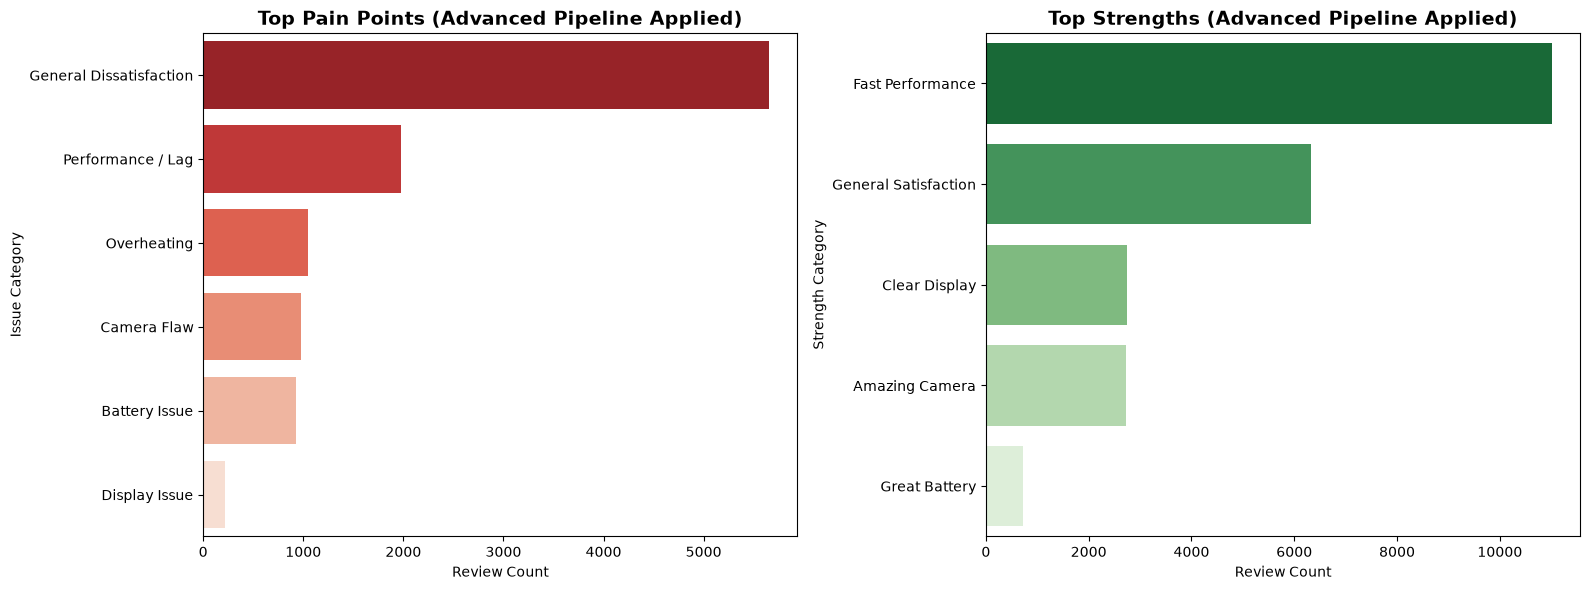

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 최종 시각화: 좌우 1x2 서브플롯 막대그래프 대조
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 좌측: Pain Points 집계
pain_counts = df['issue_category'].value_counts()
sns.barplot(
    ax=axes[0], 
    x=pain_counts.values, 
    y=pain_counts.index, 
    hue=pain_counts.index, 
    palette="Reds_r", 
    legend=False
)
axes[0].set_title("Top Pain Points (Advanced Pipeline Applied)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Review Count")
axes[0].set_ylabel("Issue Category")

# 우측: Strengths 집계
strength_counts = df['strength_category'].value_counts()
sns.barplot(
    ax=axes[1], 
    x=strength_counts.values, 
    y=strength_counts.index,
    hue=strength_counts.index,
    palette="Greens_r",
    legend=False
)
axes[1].set_title("Top Strengths (Advanced Pipeline Applied)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Review Count")
axes[1].set_ylabel("Strength Category")

plt.tight_layout()
plt.show()

In [26]:
# 브랜드별 페인 포인트 비교 집계
brand_pain = df[df['analysis_segment'] == 'Pain Point Group'].groupby(['brand', 'issue_category']).size().unstack(fill_value=0)
print(brand_pain)

issue_category  Battery Issue  Camera Flaw  Display Issue  \
brand                                                       
Apple                     124          142             36   
Google                    120          156             31   
Motorola                  129          133             27   
OnePlus                   148          145             29   
Realme                    126          140             31   
Samsung                   141          138             29   
Xiaomi                    142          121             32   

issue_category  General Dissatisfaction  Overheating  Performance / Lag  
brand                                                                    
Apple                               813          157                282  
Google                              798          158                279  
Motorola                            820          138                291  
OnePlus                             797          127                296  
Realme